# 02. 클러스터링 (비지도 학습)

**사용 데이터 (5종 통합)**
- 국민건강보험공단 건강검진정보 2024
- Personalized Medical Diet Recommendations (5,000명)
- Diet Recommendations Dataset (1,001명)
- Cardiovascular Disease Dataset (70,000명)
- Pima Indians Diabetes Database (768명)

**클러스터링 입력값**: 각 수치를 정상(0)/주의(1)/위험(2)으로 변환한 값  
**추가 입력값**: 당뇨 진단 여부(Pima), 심혈관질환 진단 여부(Cardiovascular), 질환 유형/중증도(Diet2)

## 0. 라이브러리 로드

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import joblib
import os
import warnings

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

## 1. 데이터 로드 및 통합

In [39]:
# ── 1-1. 국민건강보험공단 ──────────────────────────────────────
# 컬럼: 성별코드, 연령대코드(5세단위), 신장(5cm단위), 체중(5kg단위),
#       허리둘레, 수축기혈압, 이완기혈압, 식전혈당(공복혈당), 총콜레스테롤 등
nhis = pd.read_csv('../../data/raw/국민건강보험공단_건강검진정보_2024.CSV.csv', encoding='cp949')
nhis = nhis.rename(columns={
    '성별코드': 'gender',
    '연령대코드(5세단위)': 'age_group',
    '신장(5cm단위)': 'height',
    '체중(5kg단위)': 'weight',
    '허리둘레': 'waist',
    '수축기혈압': 'sbp',
    '이완기혈압': 'dbp',
    '식전혈당(공복혈당)': 'fbs',
})
nhis['bmi'] = (nhis['weight'] / ((nhis['height'] / 100) ** 2)).round(1)
nhis_std = pd.DataFrame({
    'sbp':      nhis['sbp'],
    'dbp':      nhis['dbp'],
    'fbs':      nhis['fbs'],
    'bmi':      nhis['bmi'],
    'waist':    nhis['waist'],
    'gender':   nhis['gender'],
    'diabetes': np.nan,
    'cardio':   np.nan,
    'disease':  np.nan,
    'severity': np.nan,
    'source':   'NHIS',
})
print(f'NHIS:              {len(nhis_std):>7,}명')

NHIS:              1,000,000명


In [40]:
# ── 1-2. Personalized Diet Recommendations ────────────────────
# 컬럼: Age, Gender, Height_cm, Weight_kg, BMI,
#       Blood_Pressure_Systolic, Blood_Pressure_Diastolic,
#       Cholesterol_Level, Blood_Sugar_Level, Chronic_Disease,
#       Recommended_Meal_Plan 등
diet1 = pd.read_csv('../../data/raw/Personalized_Diet_Recommendations.csv')
diet1_std = pd.DataFrame({
    'sbp':      diet1['Blood_Pressure_Systolic'],
    'dbp':      diet1['Blood_Pressure_Diastolic'],
    'fbs':      diet1['Blood_Sugar_Level'],
    'bmi':      diet1['BMI'],
    'waist':    np.nan,
    'gender':   np.nan,
    'diabetes': np.nan,
    'cardio':   np.nan,
    'disease':  np.nan,
    'severity': np.nan,
    'source':   'DIET1',
})
print(f'Personalized Diet: {len(diet1_std):>7,}명')

Personalized Diet:   5,000명


In [41]:
# ── 1-3. Diet Recommendations Dataset ────────────────────────
# 컬럼: Age, Gender, BMI, Disease_Type, Severity,
#       Blood_Pressure_mmHg, Glucose_mg/dL, Diet_Recommendation 등
# Disease_Type: Hypertension, Diabetes, Obesity
# Severity: Mild, Moderate, Severe
diet2 = pd.read_csv('../../data/raw/diet_recommendations_dataset.csv')

disease_map  = {'Hypertension': 1, 'Diabetes': 2, 'Obesity': 3}
severity_map = {'Mild': 1, 'Moderate': 2, 'Severe': 3}

diet2_std = pd.DataFrame({
    'sbp':      diet2['Blood_Pressure_mmHg'],
    'dbp':      np.nan,
    'fbs':      diet2['Glucose_mg/dL'],
    'bmi':      diet2['BMI'],
    'waist':    np.nan,
    'gender':   np.nan,
    'diabetes': np.nan,
    'cardio':   np.nan,
    'disease':  diet2['Disease_Type'].map(disease_map),
    'severity': diet2['Severity'].map(severity_map),
    'source':   'DIET2',
})
print(f'Diet Recomm:       {len(diet2_std):>7,}명')

Diet Recomm:         1,000명


In [42]:
# ── 1-4. Cardiovascular Disease Dataset ──────────────────────
# 컬럼: age(일), gender, height, weight, ap_hi, ap_lo,
#       cholesterol, gluc, smoke, alco, active, cardio
# cardio: 0=정상, 1=심혈관질환
cardio = pd.read_csv('../../data/raw/cardio_train.csv', sep=';')
cardio['bmi'] = (cardio['weight'] / ((cardio['height'] / 100) ** 2)).round(1)
cardio_std = pd.DataFrame({
    'sbp':      cardio['ap_hi'],
    'dbp':      cardio['ap_lo'],
    'fbs':      np.nan,
    'bmi':      cardio['bmi'],
    'waist':    np.nan,
    'gender':   cardio['gender'],
    'diabetes': np.nan,
    'cardio':   cardio['cardio'],
    'disease':  np.nan,
    'severity': np.nan,
    'source':   'CARDIO',
})
print(f'Cardiovascular:    {len(cardio_std):>7,}명')

Cardiovascular:     70,000명


In [43]:
# ── 1-5. Pima Indians Diabetes ───────────────────────────────
# 컬럼: Pregnancies, Glucose, BloodPressure, SkinThickness,
#       Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome
# Outcome: 0=정상, 1=당뇨
diabetes = pd.read_csv('../../data/raw/diabetes.csv')
diabetes_std = pd.DataFrame({
    'sbp':      np.nan,
    'dbp':      diabetes['BloodPressure'],
    'fbs':      diabetes['Glucose'],
    'bmi':      diabetes['BMI'],
    'waist':    np.nan,
    'gender':   np.nan,
    'diabetes': diabetes['Outcome'],
    'cardio':   np.nan,
    'disease':  np.nan,
    'severity': np.nan,
    'source':   'DIABETES',
})
print(f'Pima Diabetes:     {len(diabetes_std):>7,}명')

Pima Diabetes:         768명


In [44]:
# ── 1-6. 통합 ─────────────────────────────────────────────────
df_all = pd.concat(
    [nhis_std, diet1_std, diet2_std, cardio_std, diabetes_std],
    ignore_index=True
)
print(f'통합 데이터: {len(df_all):,}명')
print(df_all['source'].value_counts())

통합 데이터: 1,076,768명
source
NHIS        1000000
CARDIO        70000
DIET1          5000
DIET2          1000
DIABETES        768
Name: count, dtype: int64


## 2. 이상치 제거

In [45]:
OUTLIER_BOUNDS = {
    'sbp':   (60, 300),
    'dbp':   (40, 200),
    'fbs':   (50, 600),
    'bmi':   (10, 60),
    'waist': (40, 200),
}
before = len(df_all)
for col, (lo, hi) in OUTLIER_BOUNDS.items():
    mask = df_all[col].isna() | ((df_all[col] >= lo) & (df_all[col] <= hi))
    df_all = df_all[mask]
print(f'이상치 제거: {before:,} → {len(df_all):,}명')

이상치 제거: 1,076,768 → 1,075,235명


## 3. 정상/주의/위험 변환

국민건강보험공단 및 대한의학회 기준  
- 정상: 0 / 주의: 1 / 위험: 2

In [46]:
def classify_sbp(v):
    if pd.isna(v): return np.nan
    if v < 120:   return 0
    elif v < 140: return 1
    else:         return 2

def classify_dbp(v):
    if pd.isna(v): return np.nan
    if v < 80:   return 0
    elif v < 90: return 1
    else:        return 2

def classify_fbs(v):
    if pd.isna(v): return np.nan
    if v < 100:   return 0
    elif v < 126: return 1
    else:         return 2

def classify_bmi(v):
    if pd.isna(v): return np.nan
    if v < 23:   return 0
    elif v < 25: return 1
    else:        return 2

def classify_waist(row):
    if pd.isna(row['waist']): return np.nan
    gender = row['gender']
    waist  = row['waist']
    if gender == 2:   return 2 if waist >= 85 else 0   # 여성
    else:             return 2 if waist >= 90 else 0   # 남성(기본)

df_all['sbp_c']   = df_all['sbp'].apply(classify_sbp)
df_all['dbp_c']   = df_all['dbp'].apply(classify_dbp)
df_all['fbs_c']   = df_all['fbs'].apply(classify_fbs)
df_all['bmi_c']   = df_all['bmi'].apply(classify_bmi)
df_all['waist_c'] = df_all.apply(classify_waist, axis=1)

# 진단 여부: 이미 0/1 이진값이므로 그대로 사용
# diabetes: 0=정상, 1=당뇨
# cardio:   0=정상, 1=심혈관질환
# disease:  1=고혈압, 2=당뇨, 3=비만
# severity: 1=경증, 2=중증도, 3=중증

print('변환 완료')

변환 완료


## 4. 클러스터링 변수 준비

In [47]:
CLASS_COLS = ['sbp_c', 'dbp_c', 'fbs_c', 'bmi_c', 'waist_c',
              'diabetes', 'cardio', 'disease', 'severity']

# 결측치: 컬럼별 최빈값으로 대체
for col in CLASS_COLS:
    mode_val = df_all[col].mode()[0]
    df_all[col] = df_all[col].fillna(mode_val)
    print(f'  {col}: 결측치 → 최빈값 {mode_val:.0f} 대체')

X = df_all[CLASS_COLS].values
print(f'\n클러스터링 입력 shape: {X.shape}')

  sbp_c: 결측치 → 최빈값 1 대체
  dbp_c: 결측치 → 최빈값 0 대체
  fbs_c: 결측치 → 최빈값 0 대체
  bmi_c: 결측치 → 최빈값 2 대체
  waist_c: 결측치 → 최빈값 0 대체
  diabetes: 결측치 → 최빈값 0 대체
  cardio: 결측치 → 최빈값 0 대체
  disease: 결측치 → 최빈값 1 대체
  severity: 결측치 → 최빈값 3 대체

클러스터링 입력 shape: (1075235, 9)


## 5. 최적 클러스터 수 탐색 (Elbow + Silhouette)

In [48]:
SAMPLE_SIZE = 50000
np.random.seed(42)
idx = np.random.choice(len(X), size=min(SAMPLE_SIZE, len(X)), replace=False)
X_sample = X[idx]

K_RANGE = range(2, 10)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=10000, random_state=42))
    print(f'k={k}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

k=2  inertia=92,632  silhouette=0.3608
k=3  inertia=67,978  silhouette=0.3697
k=4  inertia=57,424  silhouette=0.3543
k=5  inertia=50,784  silhouette=0.3657
k=6  inertia=46,182  silhouette=0.3459
k=7  inertia=41,255  silhouette=0.3700
k=8  inertia=37,395  silhouette=0.3768
k=9  inertia=33,924  silhouette=0.3998


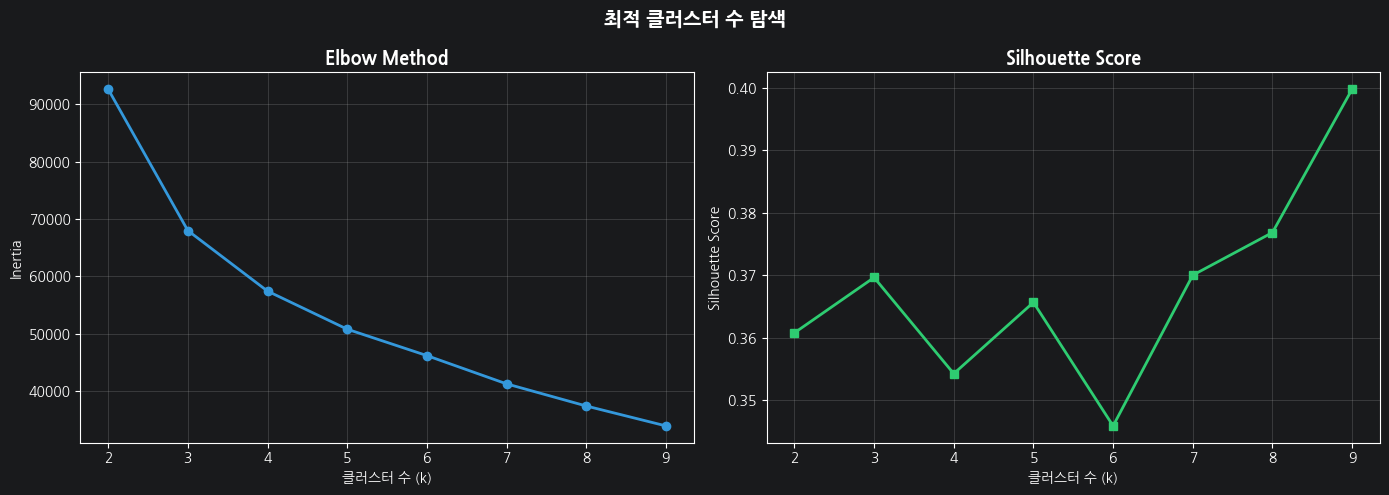

→ Elbow 그래프에서 꺾이는 지점을 확인하여 아래 K 값을 결정하세요


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#3498DB', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('클러스터 수 (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)
axes[1].plot(list(K_RANGE), sil_scores, 's-', color='#2ECC71', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('클러스터 수 (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)
plt.suptitle('최적 클러스터 수 탐색', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('→ Elbow 그래프에서 꺾이는 지점을 확인하여 아래 K 값을 결정하세요')

## 6. K-Means 클러스터링 수행

In [50]:
# Elbow 그래프 확인 후 K 직접 지정
K = 4  # 변경 가능

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_all['cluster'] = kmeans.fit_predict(X)

print(f'클러스터링 완료 (k={K})')
print(df_all['cluster'].value_counts().sort_index())

클러스터링 완료 (k=4)
cluster
0    398967
1    261416
2    219399
3    195453
Name: count, dtype: int64


## 7. 클러스터별 패턴 분석

In [51]:
# 클러스터별 평균값
cluster_summary = df_all.groupby('cluster')[CLASS_COLS].mean().round(2)
print('=== 클러스터별 평균값 ===')
print(cluster_summary)

print('\n=== 클러스터별 원본 수치 평균 ===')
print(df_all.groupby('cluster')[['sbp','dbp','fbs','bmi','waist']].mean().round(1))

=== 클러스터별 평균값 ===
         sbp_c  dbp_c  fbs_c  bmi_c  waist_c  diabetes  cardio  disease  \
cluster                                                                   
0         0.41   0.19   0.32   0.00     0.01       0.0    0.01      1.0   
1         0.93   0.62   0.69   1.86     2.00       0.0    0.00      1.0   
2         0.38   0.05   0.41   1.51     0.00       0.0    0.02      1.0   
3         1.38   1.29   0.45   1.37     0.00       0.0    0.14      1.0   

         severity  
cluster            
0             3.0  
1             3.0  
2             3.0  
3             3.0  

=== 클러스터별 원본 수치 평균 ===
           sbp   dbp    fbs   bmi  waist
cluster                                 
0        116.1  71.0   96.4  20.7   72.8
1        128.7  79.0  107.8  28.6   94.8
2        116.9  70.7   99.8  25.3   81.3
3        136.4  86.4  104.9  25.7   81.4


In [52]:
# 클러스터별 당뇨/심혈관질환 진단 비율
print('=== 클러스터별 당뇨 진단 비율(%) ===')
print((df_all.groupby('cluster')['diabetes'].mean() * 100).round(1))

print('\n=== 클러스터별 심혈관질환 진단 비율(%) ===')
print((df_all.groupby('cluster')['cardio'].mean() * 100).round(1))

print('\n=== 클러스터별 질환 유형 분포 ===')
disease_label = {0: '없음', 1: '고혈압', 2: '당뇨', 3: '비만'}
print(df_all.groupby('cluster')['disease'].value_counts().unstack(fill_value=0).rename(columns=disease_label))

=== 클러스터별 당뇨 진단 비율(%) ===
cluster
0    0.0
1    0.0
2    0.1
3    0.0
Name: diabetes, dtype: float64

=== 클러스터별 심혈관질환 진단 비율(%) ===
cluster
0     0.6
1     0.0
2     1.6
3    14.4
Name: cardio, dtype: float64

=== 클러스터별 질환 유형 분포 ===
disease     고혈압   당뇨  비만
cluster                 
0        398825   66  76
1        261416    0   0
2        219257   85  57
3        195257  107  89


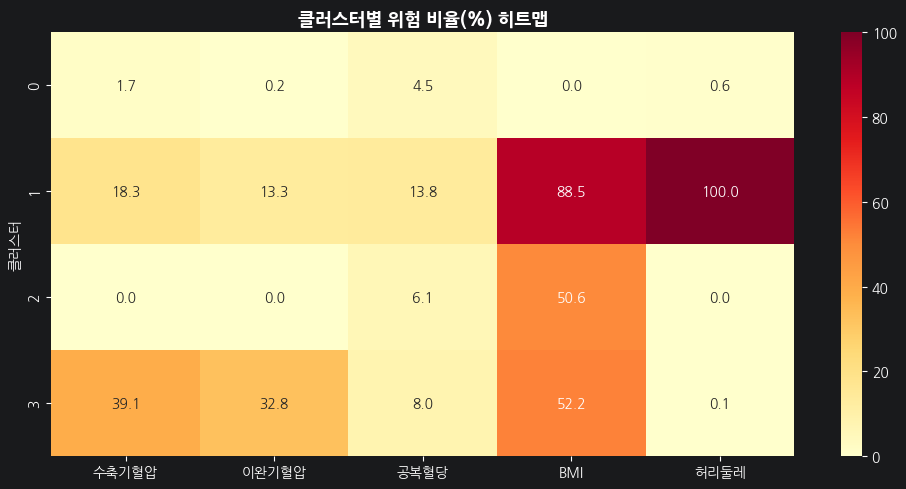

In [53]:
# 위험도 히트맵
risk_ratio = df_all.groupby('cluster')[['sbp_c','dbp_c','fbs_c','bmi_c','waist_c']].apply(
    lambda g: (g == 2).mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(risk_ratio, annot=True, fmt='.1f', cmap='YlOrRd',
            vmin=0, vmax=100, ax=ax,
            xticklabels=['수축기혈압', '이완기혈압', '공복혈당', 'BMI', '허리둘레'])
ax.set_title('클러스터별 위험 비율(%) 히트맵', fontsize=13, fontweight='bold')
ax.set_ylabel('클러스터')
plt.tight_layout()
plt.show()

## 8. PCA 2D 시각화

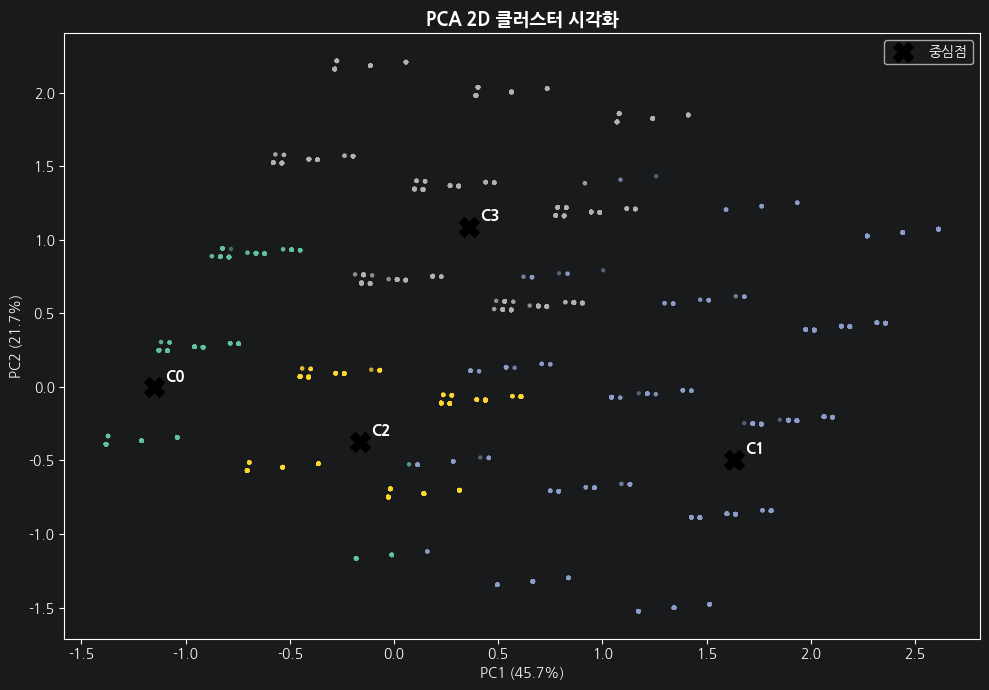

In [54]:
pca = PCA(n_components=2, random_state=42)
VIZ_SIZE = 20000
viz_idx = np.random.choice(len(X), size=min(VIZ_SIZE, len(X)), replace=False)
X_pca = pca.fit_transform(X[viz_idx])
labels_viz = df_all['cluster'].values[viz_idx]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_viz, cmap='Set2', alpha=0.4, s=5)
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='black', marker='X', s=200, zorder=5, label='중심점')
for i, (x, y) in enumerate(centers_pca):
    ax.annotate(f'C{i}', (x, y), textcoords='offset points', xytext=(8, 5), fontsize=11, fontweight='bold')
ax.set_title('PCA 2D 클러스터 시각화', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. 저장

In [55]:
os.makedirs('../../data/processed', exist_ok=True)
os.makedirs('../../models/diet', exist_ok=True)

df_all.to_csv('../../data/processed/health_clustered.csv', index=False, encoding='utf-8-sig')
joblib.dump(kmeans, '../../models/diet/kmeans_model.pkl')

print('저장 완료')
print('  data/processed/health_clustered.csv  → 03_classification 입력')
print('  models/diet/kmeans_model.pkl')

저장 완료
  data/processed/health_clustered.csv  → 03_classification 입력
  models/diet/kmeans_model.pkl


## 10. 결과 요약

In [56]:
print('=' * 60)
print('클러스터링 결과 요약')
print('=' * 60)
print(f'통합 데이터 규모  : {len(df_all):,}명')
print(f'클러스터 수       : {K}')
print(f'클러스터링 입력값 : 정상/주의/위험 변환값 + 당뇨/심혈관질환 진단 여부 + 질환유형/중증도')
print()
for cid in range(K):
    n   = (df_all['cluster'] == cid).sum()
    row = cluster_summary.loc[cid]
    print(f'클러스터 {cid}: {n:,}명')
    print(f'  sbp={row["sbp_c"]:.2f}  dbp={row["dbp_c"]:.2f}  fbs={row["fbs_c"]:.2f}  bmi={row["bmi_c"]:.2f}  waist={row["waist_c"]:.2f}')
    print(f'  diabetes={row["diabetes"]:.2f}  cardio={row["cardio"]:.2f}  disease={row["disease"]:.2f}  severity={row["severity"]:.2f}')
print()
print('→ 다음 단계: 03_classification.ipynb')
print('=' * 60)

클러스터링 결과 요약
통합 데이터 규모  : 1,075,235명
클러스터 수       : 4
클러스터링 입력값 : 정상/주의/위험 변환값 + 당뇨/심혈관질환 진단 여부 + 질환유형/중증도

클러스터 0: 398,967명
  sbp=0.41  dbp=0.19  fbs=0.32  bmi=0.00  waist=0.01
  diabetes=0.00  cardio=0.01  disease=1.00  severity=3.00
클러스터 1: 261,416명
  sbp=0.93  dbp=0.62  fbs=0.69  bmi=1.86  waist=2.00
  diabetes=0.00  cardio=0.00  disease=1.00  severity=3.00
클러스터 2: 219,399명
  sbp=0.38  dbp=0.05  fbs=0.41  bmi=1.51  waist=0.00
  diabetes=0.00  cardio=0.02  disease=1.00  severity=3.00
클러스터 3: 195,453명
  sbp=1.38  dbp=1.29  fbs=0.45  bmi=1.37  waist=0.00
  diabetes=0.00  cardio=0.14  disease=1.00  severity=3.00

→ 다음 단계: 03_classification.ipynb
